In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(r"C:\Users\navon\OneDrive\Desktop\CrossRank")
(ROOT / "results/charts").mkdir(parents=True, exist_ok=True)

# load everything we'll need
v1_summary = json.load(open(ROOT / "results/tables/v1_summary.json"))
v2_summary = json.load(open(ROOT / "results/tables/v2_summary.json"))
v3_summary = json.load(open(ROOT / "results/tables/v3_summary.json"))
notebook04_summary = json.load(open(ROOT / "results/tables/notebook04_summary.json"))
model_comparison = pd.read_csv(ROOT / "results/tables/v3_full_model_comparison.csv")
net_df = pd.read_csv(ROOT / "results/tables/portfolio_gross_net_comparison.csv")
regime_detail = pd.read_csv(ROOT / "results/tables/regime_performance_detail.csv")

print("All result files loaded.")
print(model_comparison)

All result files loaded.
                  model   mean_ic      nw_p
0              LightGBM  0.037691  0.016211
1                    RF  0.042469  0.010411
2                    LR -0.046800  0.043274
3  Ensemble_RF_LightGBM  0.043768  0.005311
4         Ensemble_all3  0.018691  0.317770


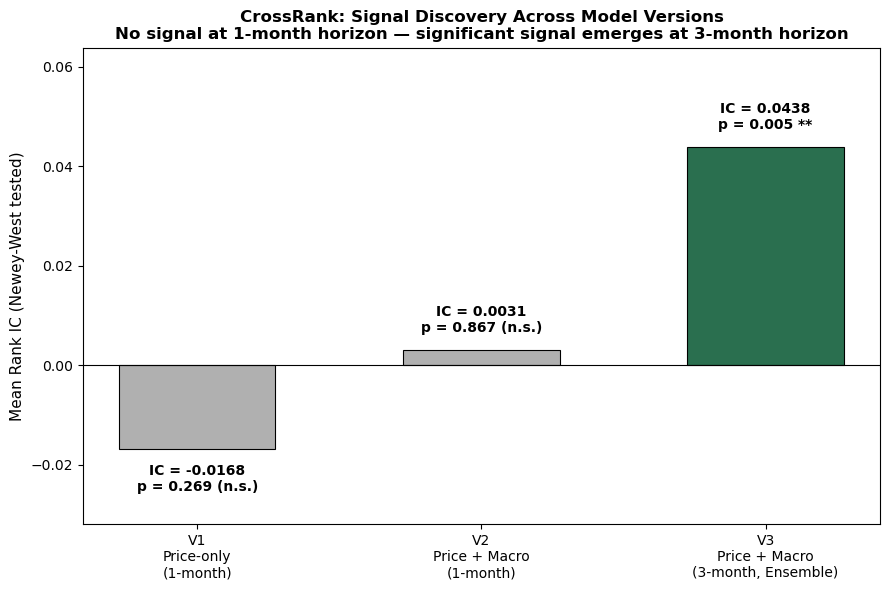

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\06_ic_progression.png


In [2]:
fig, ax = plt.subplots(figsize=(9, 6))

stages = ["V1\nPrice-only\n(1-month)", "V2\nPrice + Macro\n(1-month)", "V3\nPrice + Macro\n(3-month, Ensemble)"]
ics = [v1_summary["mean_ic"], v2_summary["mean_ic"], notebook04_summary["V3_ensemble_RF_LightGBM"]["mean_ic"]]
pvals = [v1_summary["p_value"], v2_summary["p_value"], notebook04_summary["V3_ensemble_RF_LightGBM"]["nw_p_value"]]
colors = ["#b0b0b0", "#b0b0b0", "#2a6f4f"]  # grey for null results, green for the significant one

bars = ax.bar(stages, ics, color=colors, width=0.55, edgecolor="black", linewidth=0.8)

for bar, ic, p in zip(bars, ics, pvals):
    height = bar.get_height()
    sig_label = f"p = {p:.3f}" + (" **" if p < 0.05 else " (n.s.)")
    va = "bottom" if height >= 0 else "top"
    offset = 0.003 if height >= 0 else -0.003
    ax.text(bar.get_x() + bar.get_width()/2, height + offset, f"IC = {ic:.4f}\n{sig_label}",
            ha="center", va=va, fontsize=10, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean Rank IC (Newey-West tested)", fontsize=11)
ax.set_title("CrossRank: Signal Discovery Across Model Versions\nNo signal at 1-month horizon — significant signal emerges at 3-month horizon",
             fontsize=12, fontweight="bold")
ax.set_ylim(min(ics)-0.015, max(ics)+0.02)
plt.tight_layout()

out_path = ROOT / "results/charts/06_ic_progression.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

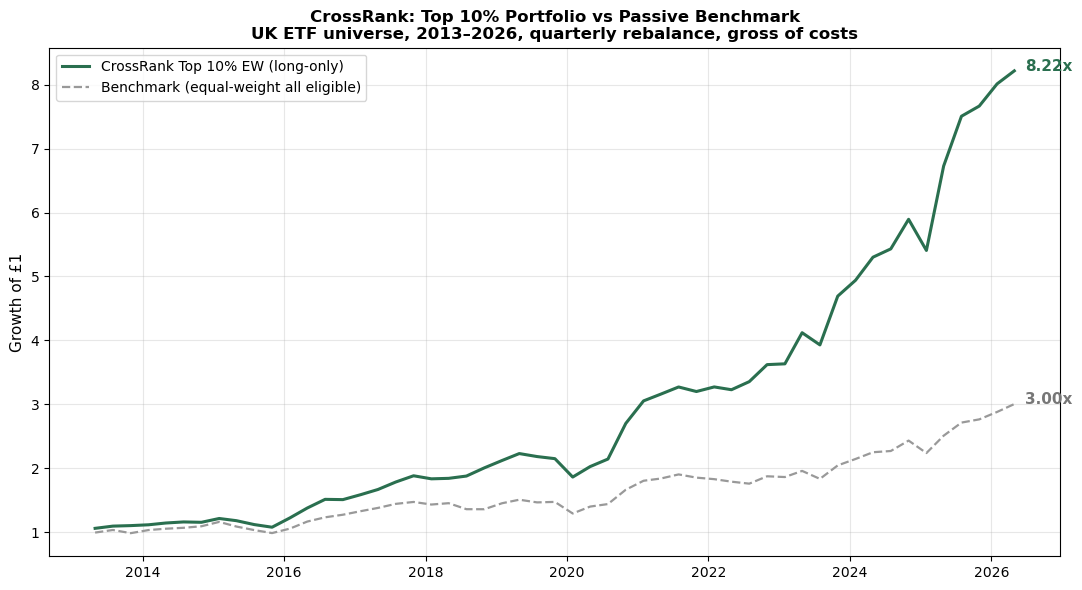

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\01_equity_curve.png
Final growth — Top 10%: 8.22x | Benchmark: 3.00x


In [3]:
port_rets = pd.read_csv(ROOT / "results/tables/portfolio_return_series.csv", parse_dates=["date"])
port_rets = port_rets.sort_values("date").reset_index(drop=True)

port_rets["top10_growth"] = (1 + port_rets["top10_ew_ret"]).cumprod()
port_rets["bench_growth"] = (1 + port_rets["benchmark_ret"]).cumprod()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(port_rets["date"], port_rets["top10_growth"], label="CrossRank Top 10% EW (long-only)",
        color="#2a6f4f", linewidth=2.2)
ax.plot(port_rets["date"], port_rets["bench_growth"], label="Benchmark (equal-weight all eligible)",
        color="#999999", linewidth=1.6, linestyle="--")

final_top10 = port_rets["top10_growth"].iloc[-1]
final_bench = port_rets["bench_growth"].iloc[-1]
ax.annotate(f"{final_top10:.2f}x", xy=(port_rets["date"].iloc[-1], final_top10),
            xytext=(8, 0), textcoords="offset points", fontsize=11, fontweight="bold", color="#2a6f4f")
ax.annotate(f"{final_bench:.2f}x", xy=(port_rets["date"].iloc[-1], final_bench),
            xytext=(8, 0), textcoords="offset points", fontsize=11, fontweight="bold", color="#777777")

ax.set_ylabel("Growth of £1", fontsize=11)
ax.set_title("CrossRank: Top 10% Portfolio vs Passive Benchmark\nUK ETF universe, 2013–2026, quarterly rebalance, gross of costs",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

out_path = ROOT / "results/charts/01_equity_curve.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print(f"Final growth — Top 10%: {final_top10:.2f}x | Benchmark: {final_bench:.2f}x")

In [4]:
import yfinance as yf

ftse_allshare = yf.download("^FTAS", period="max", auto_adjust=True, progress=False)
if isinstance(ftse_allshare.columns, pd.MultiIndex):
    ftse_allshare.columns = ftse_allshare.columns.get_level_values(0)

ftse_monthly = ftse_allshare["Close"].resample("ME").last()
ftse_ret = ftse_monthly.pct_change()

# align to our quarterly rebalance dates, compute 3-month forward return at each
ftse_quarterly_ret = ftse_monthly.resample("QE").last().pct_change()
ftse_aligned = ftse_quarterly_ret.reindex(port_rets["date"], method="nearest")

port_rets["ftse_ret"] = ftse_aligned.values
port_rets["ftse_growth"] = (1 + port_rets["ftse_ret"].fillna(0)).cumprod()

print(port_rets[["date","ftse_ret","ftse_growth"]].tail())

         date  ftse_ret  ftse_growth
48 2025-04-30  0.034876     1.494668
49 2025-07-31  0.032260     1.542886
50 2025-10-31  0.060541     1.636295
51 2026-01-31  0.057026     1.729606
52 2026-04-30  0.015010     1.755568


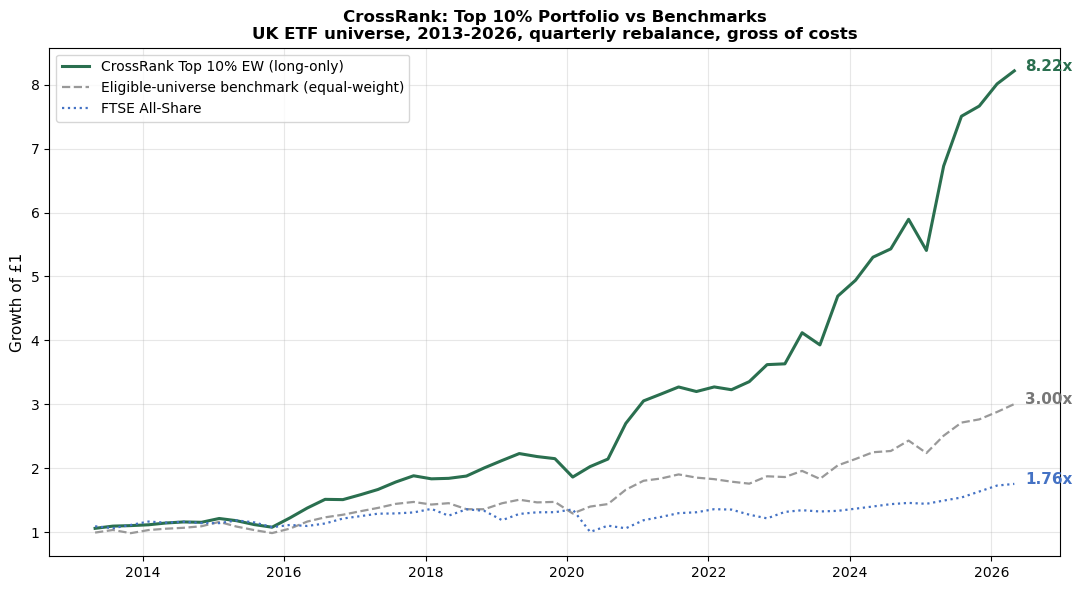

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\01b_equity_curve_with_ftse.png
Final growth: Top10=8.22x Bench=3.00x FTSE=1.76x


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(port_rets["date"], port_rets["top10_growth"], label="CrossRank Top 10% EW (long-only)",
        color="#2a6f4f", linewidth=2.2)
ax.plot(port_rets["date"], port_rets["bench_growth"], label="Eligible-universe benchmark (equal-weight)",
        color="#999999", linewidth=1.6, linestyle="--")
ax.plot(port_rets["date"], port_rets["ftse_growth"], label="FTSE All-Share",
        color="#4472c4", linewidth=1.6, linestyle=":")

final_top10 = port_rets["top10_growth"].iloc[-1]
final_bench = port_rets["bench_growth"].iloc[-1]
final_ftse = port_rets["ftse_growth"].iloc[-1]

ax.annotate(f"{final_top10:.2f}x", xy=(port_rets["date"].iloc[-1], final_top10),
            xytext=(8, 0), textcoords="offset points", fontsize=11, fontweight="bold", color="#2a6f4f")
ax.annotate(f"{final_bench:.2f}x", xy=(port_rets["date"].iloc[-1], final_bench),
            xytext=(8, 0), textcoords="offset points", fontsize=11, fontweight="bold", color="#777777")
ax.annotate(f"{final_ftse:.2f}x", xy=(port_rets["date"].iloc[-1], final_ftse),
            xytext=(8, 0), textcoords="offset points", fontsize=11, fontweight="bold", color="#4472c4")

title_line1 = "CrossRank: Top 10% Portfolio vs Benchmarks"
title_line2 = "UK ETF universe, 2013-2026, quarterly rebalance, gross of costs"
ax.set_title(title_line1 + "\n" + title_line2, fontsize=12, fontweight="bold")

ax.set_ylabel("Growth of £1", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

out_path = ROOT / "results/charts/01b_equity_curve_with_ftse.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print(f"Final growth: Top10={final_top10:.2f}x Bench={final_bench:.2f}x FTSE={final_ftse:.2f}x")

In [8]:
prices = pd.read_csv(ROOT / "data/processed/uk_etf_prices.csv", parse_dates=["date"])
print(f"Prices loaded: {len(prices):,} rows")

Prices loaded: 2,707,129 rows


In [9]:
ftse_etf_prices = prices[prices["ticker"] == "ISF"].sort_values("date").set_index("date")["close"]

# exact 3-month forward return at EVERY available date, same method as fwd_ret_3m
ftse_monthly_close = ftse_etf_prices.resample("ME").last()
ftse_fwd_3m = (ftse_monthly_close.shift(-3) / ftse_monthly_close) - 1

ftse_aligned = ftse_fwd_3m.reindex(port_rets["date"])
port_rets["ftse_ret"] = ftse_aligned.values
port_rets["ftse_growth"] = (1 + port_rets["ftse_ret"].fillna(0)).cumprod()

print(f"Missing FTSE values after proper alignment: {port_rets['ftse_ret'].isna().sum()}")
print(port_rets[["date","ftse_ret","ftse_growth"]].tail())

Missing FTSE values after proper alignment: 0
         date  ftse_ret  ftse_growth
48 2025-04-30  0.068930     1.387717
49 2025-07-31  0.064110     1.476684
50 2025-10-31  0.052101     1.553621
51 2026-01-31  0.021322     1.586747
52 2026-04-30  0.040609     1.651184


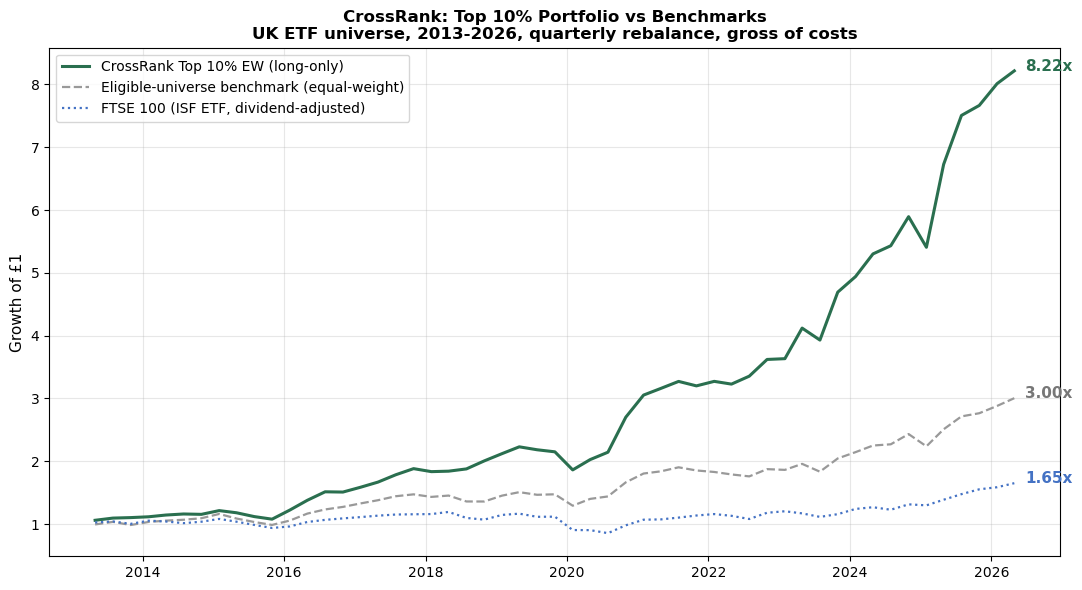

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\01b_equity_curve_with_ftse.png
Final growth: Top10=8.22x Bench=3.00x FTSE100=1.65x


In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(port_rets["date"], port_rets["top10_growth"], label="CrossRank Top 10% EW (long-only)",
        color="#2a6f4f", linewidth=2.2)
ax.plot(port_rets["date"], port_rets["bench_growth"], label="Eligible-universe benchmark (equal-weight)",
        color="#999999", linewidth=1.6, linestyle="--")
ax.plot(port_rets["date"], port_rets["ftse_growth"], label="FTSE 100 (ISF ETF, dividend-adjusted)",
        color="#4472c4", linewidth=1.6, linestyle=":")

final_top10 = port_rets["top10_growth"].iloc[-1]
final_bench = port_rets["bench_growth"].iloc[-1]
final_ftse = port_rets["ftse_growth"].iloc[-1]

ax.annotate(f"{final_top10:.2f}x", xy=(port_rets["date"].iloc[-1], final_top10),
            xytext=(8, 0), textcoords="offset points", fontsize=11, fontweight="bold", color="#2a6f4f")
ax.annotate(f"{final_bench:.2f}x", xy=(port_rets["date"].iloc[-1], final_bench),
            xytext=(8, 0), textcoords="offset points", fontsize=11, fontweight="bold", color="#777777")
ax.annotate(f"{final_ftse:.2f}x", xy=(port_rets["date"].iloc[-1], final_ftse),
            xytext=(8, 0), textcoords="offset points", fontsize=11, fontweight="bold", color="#4472c4")

title_line1 = "CrossRank: Top 10% Portfolio vs Benchmarks"
title_line2 = "UK ETF universe, 2013-2026, quarterly rebalance, gross of costs"
ax.set_title(title_line1 + "\n" + title_line2, fontsize=12, fontweight="bold")

ax.set_ylabel("Growth of £1", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

out_path = ROOT / "results/charts/01b_equity_curve_with_ftse.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print(f"Final growth: Top10={final_top10:.2f}x Bench={final_bench:.2f}x FTSE100={final_ftse:.2f}x")

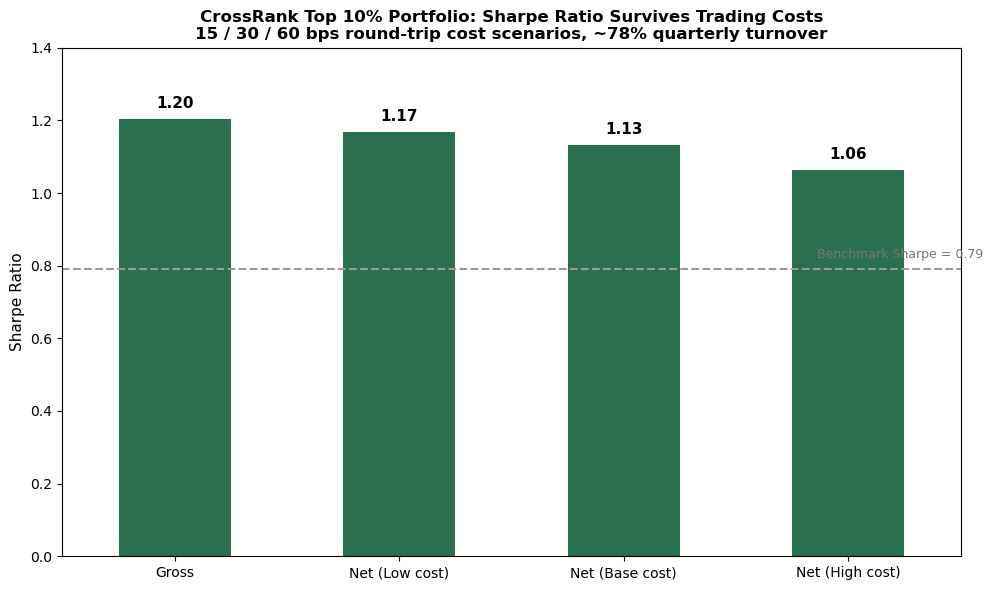

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\03_cost_sensitivity.png


In [11]:
net_df_melted = net_df.set_index("variant")

sharpe_data = {
    "Gross": net_df_melted["gross_sharpe"],
    "Net (Low cost)": net_df_melted["net_sharpe_Low (15bps round-trip)"],
    "Net (Base cost)": net_df_melted["net_sharpe_Base (30bps round-trip)"],
    "Net (High cost)": net_df_melted["net_sharpe_High (60bps round-trip)"],
}
sharpe_df = pd.DataFrame(sharpe_data)

fig, ax = plt.subplots(figsize=(10, 6))
sharpe_df.loc[["Top 10% EW"]].T.plot(kind="bar", ax=ax, color=["#2a6f4f"], legend=False, width=0.5)

for i, (label, val) in enumerate(zip(sharpe_df.columns, sharpe_df.loc["Top 10% EW"])):
    ax.text(i, val + 0.03, f"{val:.2f}", ha="center", fontweight="bold", fontsize=11)

bench_sharpe = 0.792
ax.axhline(bench_sharpe, color="#999999", linestyle="--", linewidth=1.5)
ax.text(3.6, bench_sharpe + 0.03, f"Benchmark Sharpe = {bench_sharpe:.2f}", color="#777777", fontsize=9, ha="right")

title_line1 = "CrossRank Top 10% Portfolio: Sharpe Ratio Survives Trading Costs"
title_line2 = "15 / 30 / 60 bps round-trip cost scenarios, ~78% quarterly turnover"
ax.set_title(title_line1 + "\n" + title_line2, fontsize=12, fontweight="bold")
ax.set_ylabel("Sharpe Ratio", fontsize=11)
ax.set_xticklabels(sharpe_df.columns, rotation=0)
ax.set_ylim(0, 1.4)
plt.tight_layout()

out_path = ROOT / "results/charts/03_cost_sensitivity.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

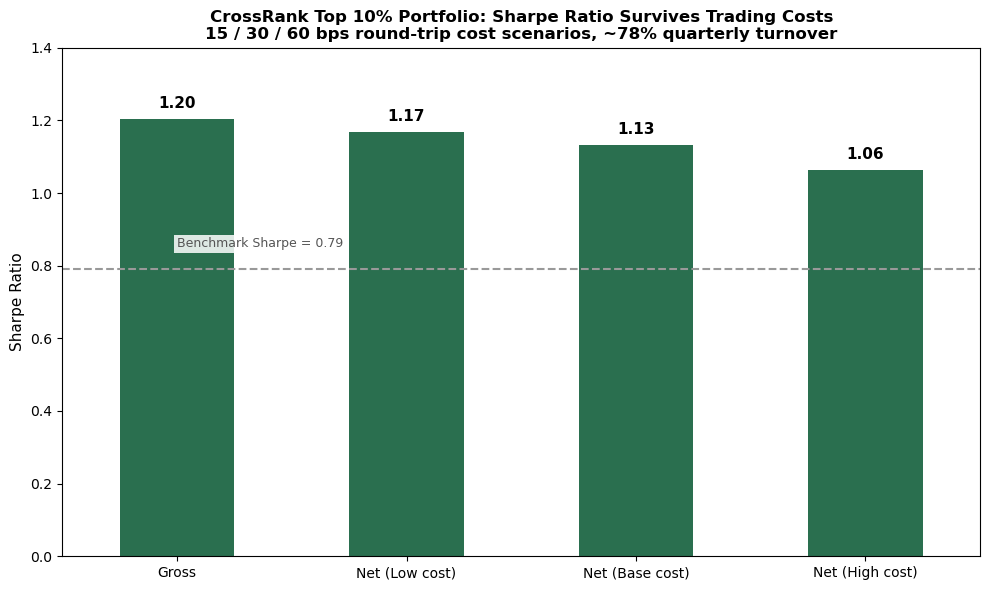

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\03_cost_sensitivity.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sharpe_df.loc[["Top 10% EW"]].T.plot(kind="bar", ax=ax, color=["#2a6f4f"], legend=False, width=0.5)

for i, (label, val) in enumerate(zip(sharpe_df.columns, sharpe_df.loc["Top 10% EW"])):
    ax.text(i, val + 0.03, f"{val:.2f}", ha="center", fontweight="bold", fontsize=11)

bench_sharpe = 0.792
ax.axhline(bench_sharpe, color="#999999", linestyle="--", linewidth=1.5)
ax.text(0.0, bench_sharpe + 0.05, f"Benchmark Sharpe = {bench_sharpe:.2f}",
        color="#555555", fontsize=9, ha="left", va="bottom",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2))

title_line1 = "CrossRank Top 10% Portfolio: Sharpe Ratio Survives Trading Costs"
title_line2 = "15 / 30 / 60 bps round-trip cost scenarios, ~78% quarterly turnover"
ax.set_title(title_line1 + "\n" + title_line2, fontsize=12, fontweight="bold")
ax.set_ylabel("Sharpe Ratio", fontsize=11)
ax.set_xticklabels(sharpe_df.columns, rotation=0)
ax.set_ylim(0, 1.4)
plt.tight_layout()

out_path = ROOT / "results/charts/03_cost_sensitivity.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

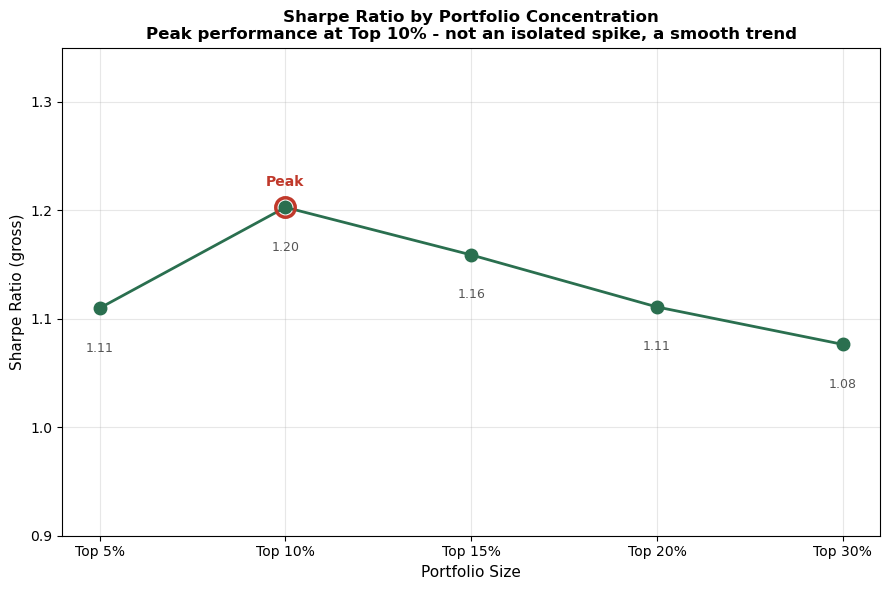

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\04_portfolio_size_sensitivity.png


In [13]:
with open(ROOT / "results/tables/robustness_portfolio_size.json") as f:
    size_variants = json.load(f)

sizes = list(size_variants.keys())
sharpes = [size_variants[s]["sharpe"] for s in sizes]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sizes, sharpes, marker="o", markersize=9, linewidth=2, color="#2a6f4f")

# highlight the winner
best_idx = sharpes.index(max(sharpes))
ax.plot(sizes[best_idx], sharpes[best_idx], marker="o", markersize=14,
        markerfacecolor="none", markeredgecolor="#c0392b", markeredgewidth=2.5)
ax.annotate("Peak", xy=(sizes[best_idx], sharpes[best_idx]), xytext=(0, 15),
            textcoords="offset points", ha="center", color="#c0392b", fontweight="bold")

for x, y in zip(sizes, sharpes):
    ax.text(x, y - 0.04, f"{y:.2f}", ha="center", fontsize=9, color="#555555")

title_line1 = "Sharpe Ratio by Portfolio Concentration"
title_line2 = "Peak performance at Top 10% - not an isolated spike, a smooth trend"
ax.set_title(title_line1 + "\n" + title_line2, fontsize=12, fontweight="bold")
ax.set_ylabel("Sharpe Ratio (gross)", fontsize=11)
ax.set_xlabel("Portfolio Size", fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0.9, 1.35)
plt.tight_layout()

out_path = ROOT / "results/charts/04_portfolio_size_sensitivity.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [15]:
import numpy as np

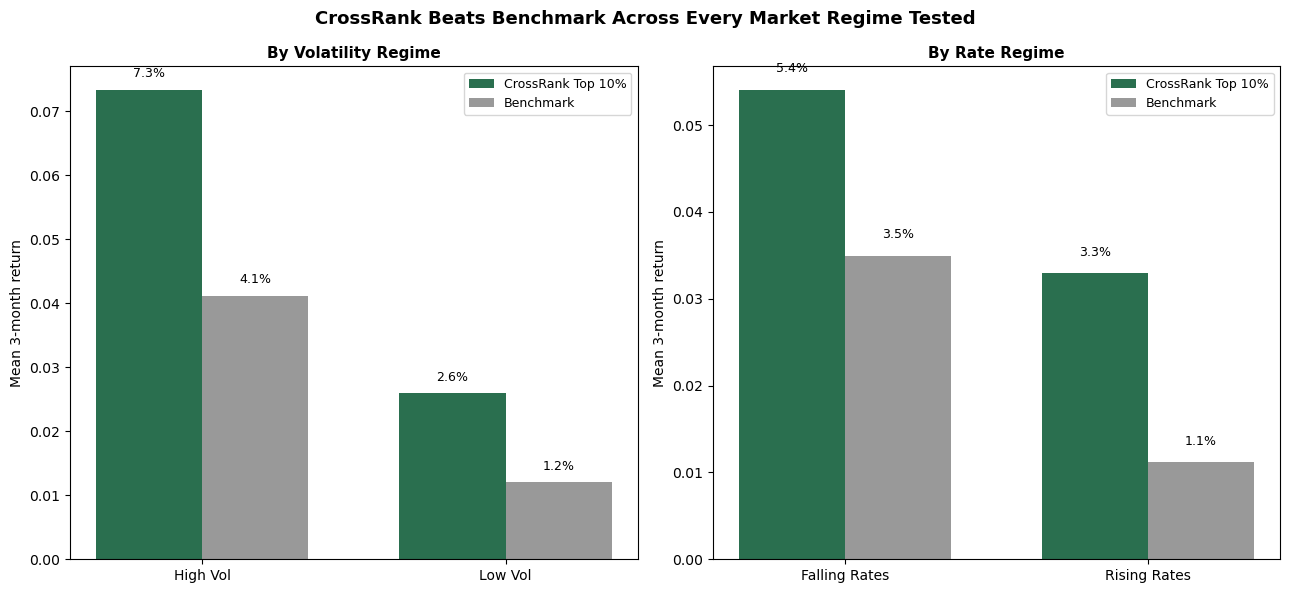

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\05_regime_breakdown.png


In [16]:
regime_vol = regime_detail.groupby("vol_regime")[["port_ret","bench_ret"]].mean()
regime_rate = regime_detail.groupby("rate_regime")[["port_ret","bench_ret"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

x = np.arange(len(regime_vol))
width = 0.35
axes[0].bar(x - width/2, regime_vol["port_ret"], width, label="CrossRank Top 10%", color="#2a6f4f")
axes[0].bar(x + width/2, regime_vol["bench_ret"], width, label="Benchmark", color="#999999")
axes[0].set_xticks(x)
axes[0].set_xticklabels(regime_vol.index)
axes[0].set_ylabel("Mean 3-month return")
axes[0].set_title("By Volatility Regime", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
for i, (p, b) in enumerate(zip(regime_vol["port_ret"], regime_vol["bench_ret"])):
    axes[0].text(i - width/2, p + 0.002, f"{p:.1%}", ha="center", fontsize=9)
    axes[0].text(i + width/2, b + 0.002, f"{b:.1%}", ha="center", fontsize=9)

x2 = np.arange(len(regime_rate))
axes[1].bar(x2 - width/2, regime_rate["port_ret"], width, label="CrossRank Top 10%", color="#2a6f4f")
axes[1].bar(x2 + width/2, regime_rate["bench_ret"], width, label="Benchmark", color="#999999")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(regime_rate.index)
axes[1].set_ylabel("Mean 3-month return")
axes[1].set_title("By Rate Regime", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
for i, (p, b) in enumerate(zip(regime_rate["port_ret"], regime_rate["bench_ret"])):
    axes[1].text(i - width/2, p + 0.002, f"{p:.1%}", ha="center", fontsize=9)
    axes[1].text(i + width/2, b + 0.002, f"{b:.1%}", ha="center", fontsize=9)

fig.suptitle("CrossRank Beats Benchmark Across Every Market Regime Tested", fontsize=13, fontweight="bold")
plt.tight_layout()

out_path = ROOT / "results/charts/05_regime_breakdown.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

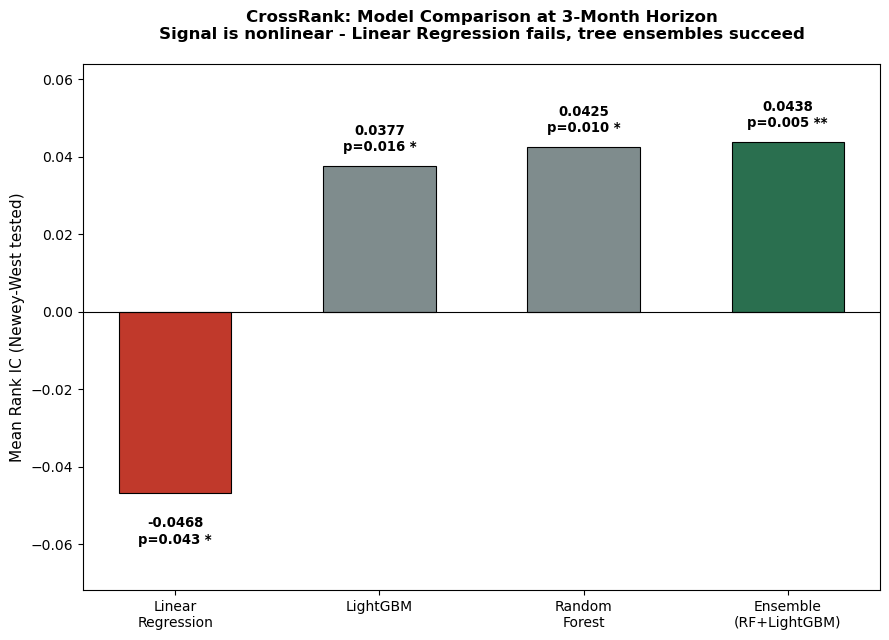

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\02_model_comparison.png


In [18]:
model_order = ["LR", "LightGBM", "RF", "Ensemble_RF_LightGBM"]
display_names = ["Linear\nRegression", "LightGBM", "Random\nForest", "Ensemble\n(RF+LightGBM)"]

plot_data = model_comparison.set_index("model").loc[model_order]
colors = ["#c0392b" if ic < 0 else "#7f8c8d" for ic in plot_data["mean_ic"]]
colors[model_order.index("Ensemble_RF_LightGBM")] = "#2a6f4f"

fig, ax = plt.subplots(figsize=(9, 6.5))
bars = ax.bar(display_names, plot_data["mean_ic"], color=colors, edgecolor="black", linewidth=0.8, width=0.55)

for bar, ic, p in zip(bars, plot_data["mean_ic"], plot_data["nw_p"]):
    height = bar.get_height()
    sig = "**" if p < 0.01 else ("*" if p < 0.05 else "n.s.")
    if height >= 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.003,
                f"{ic:.4f}\np={p:.3f} {sig}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    else:
        ax.text(bar.get_x() + bar.get_width()/2, height - 0.006,
                f"{ic:.4f}\np={p:.3f} {sig}", ha="center", va="top", fontsize=9.5, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)

title_line1 = "CrossRank: Model Comparison at 3-Month Horizon"
title_line2 = "Signal is nonlinear - Linear Regression fails, tree ensembles succeed"
ax.set_title(title_line1 + "\n" + title_line2, fontsize=12, fontweight="bold", pad=18)
ax.set_ylabel("Mean Rank IC (Newey-West tested)", fontsize=11)

ax.set_ylim(plot_data["mean_ic"].min() - 0.025, plot_data["mean_ic"].max() + 0.02)

plt.tight_layout()

out_path = ROOT / "results/charts/02_model_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [19]:
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import pandas_datareader.data as web
import datetime

FEATURE_COLS = ["mom_1m","mom_3m","mom_6m","mom_12m","realized_vol","max_drawdown_12m"]
MACRO_COLS = ["uk_rate", "uk_gilt_10y", "gbpusd", "vix"]
FEATURE_COLS_V2 = FEATURE_COLS + MACRO_COLS

base = pd.read_csv(ROOT / "data/processed/uk_etf_features_targets.csv", parse_dates=["date"])
base = base.sort_values(["ticker", "date"]).reset_index(drop=True)
base["fwd_ret_3m"] = (
    base.groupby("ticker")["ret"]
    .transform(lambda s: (1 + s.shift(-1)) * (1 + s.shift(-2)) * (1 + s.shift(-3)) - 1)
)
base["xs_excess_ret_3m"] = base["fwd_ret_3m"] - base.groupby("date")["fwd_ret_3m"].transform("mean")
for col in FEATURE_COLS:
    base[col] = base.groupby("ticker")[col].shift(1)

start = datetime.datetime(2008, 1, 1)
end = datetime.datetime(2026, 10, 31)
series_codes = {"uk_rate": "IUDZLS9", "uk_gilt_10y": "IRLTLT01GBM156N", "gbpusd": "DEXUSUK", "vix": "VIXCLS"}
macro_raw = {name: web.DataReader(code, "fred", start, end) for name, code in series_codes.items()}
macro_monthly = {name: s[s.columns[0]].resample("ME").last().ffill() for name, s in macro_raw.items()}
macro_df = pd.DataFrame(macro_monthly).reset_index().rename(columns={"DATE": "date"})
macro_lagged = macro_df.copy()
macro_lagged[MACRO_COLS] = macro_lagged[MACRO_COLS].shift(1)

data_v3 = base.merge(macro_lagged, on="date", how="left")
required_complete = FEATURE_COLS + ["uk_gilt_10y","gbpusd","vix","xs_excess_ret_3m"]
data_v3 = data_v3.dropna(subset=required_complete).reset_index(drop=True)

print(f"data_v3 rebuilt: {len(data_v3):,} rows")

# train final models on the FULL dataset (not walk-forward) purely for interpretability
X = data_v3[FEATURE_COLS_V2]
y = data_v3["xs_excess_ret_3m"]
X_filled = X.fillna(0)

lgb_final = lgb.LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                               min_child_samples=20, random_state=42, verbose=-1)
lgb_final.fit(X, y)

rf_final = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=20,
                                  random_state=42, n_jobs=-1)
rf_final.fit(X_filled, y)

importance_df = pd.DataFrame({
    "feature": FEATURE_COLS_V2,
    "LightGBM": lgb_final.feature_importances_ / lgb_final.feature_importances_.sum(),
    "RF": rf_final.feature_importances_ / rf_final.feature_importances_.sum(),
})
importance_df = importance_df.sort_values("LightGBM", ascending=False)
print(importance_df)

data_v3 rebuilt: 36,930 rows
            feature  LightGBM        RF
7       uk_gilt_10y  0.153963  0.205427
3           mom_12m  0.114329  0.072812
5  max_drawdown_12m  0.109756  0.168135
1            mom_3m  0.103277  0.147362
4      realized_vol  0.101372  0.090638
8            gbpusd  0.100610  0.139108
2            mom_6m  0.096418  0.057574
6           uk_rate  0.089177  0.056784
0            mom_1m  0.076220  0.034889
9               vix  0.054878  0.027271


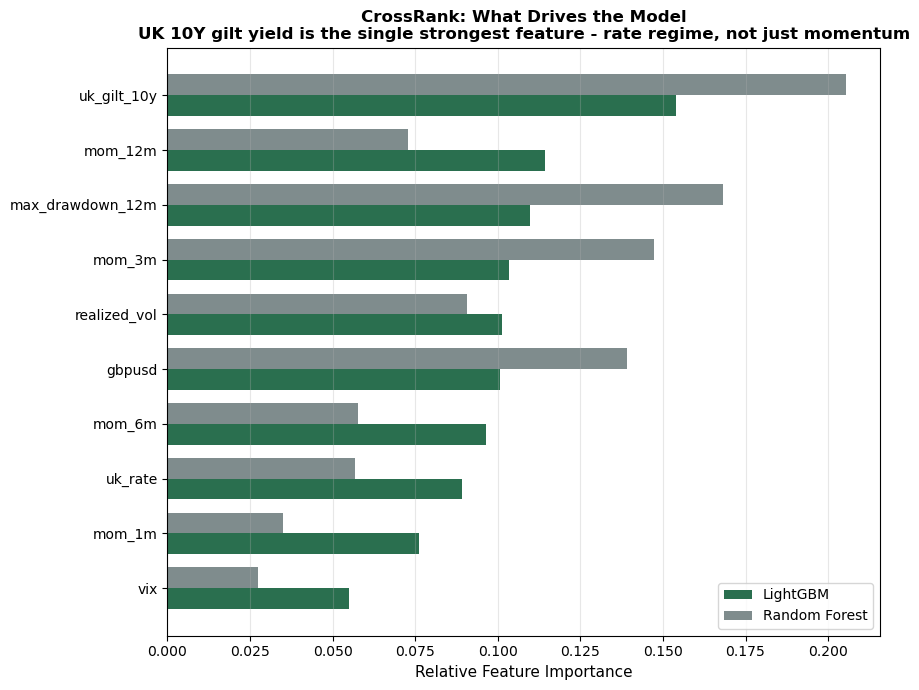

Saved: C:\Users\navon\OneDrive\Desktop\CrossRank\results\charts\07_feature_importance.png


In [20]:
importance_plot = importance_df.set_index("feature").sort_values("LightGBM")

fig, ax = plt.subplots(figsize=(9, 7))
y_pos = np.arange(len(importance_plot))
width = 0.38

ax.barh(y_pos - width/2, importance_plot["LightGBM"], height=width, label="LightGBM", color="#2a6f4f")
ax.barh(y_pos + width/2, importance_plot["RF"], height=width, label="Random Forest", color="#7f8c8d")

ax.set_yticks(y_pos)
ax.set_yticklabels(importance_plot.index)
ax.set_xlabel("Relative Feature Importance", fontsize=11)

title_line1 = "CrossRank: What Drives the Model"
title_line2 = "UK 10Y gilt yield is the single strongest feature - rate regime, not just momentum"
ax.set_title(title_line1 + "\n" + title_line2, fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

out_path = ROOT / "results/charts/07_feature_importance.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")